In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
import nltk
from nltk.tokenize import word_tokenize
import fasttext.util

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Load pre-trained FastText model
print("Loading FastText model...")
fasttext.util.download_model('en', if_exists='ignore')  # Download English model if not already present
ft_model = fasttext.load_model('cc.en.300.bin')  # 300-dimensional vectors

# Step 3: Convert text data to numeric features using FastText
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])

# Step 4: Apply Min-Max Scaling to ensure non-negative values
print("Applying Min-Max Scaling...")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Target labels
y = data[target_column]

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 6: Initialize and train the Multinomial Naive Bayes model
print("Training Multinomial Naive Bayes model...")
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)

# Step 7: Save the trained Multinomial Naive Bayes model
model_path = r"C:\Users\PC\Downloads\MultinomialNB_model_fasttext.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(mnb_model, f)
print(f"Trained Multinomial Naive Bayes model saved to {model_path}")

# Step 8: Evaluate the Multinomial Naive Bayes model
y_pred_mnb = mnb_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_mnb)
precision = precision_score(y_test, y_pred_mnb, average='weighted')
recall = recall_score(y_test, y_pred_mnb, average='weighted')
f1 = f1_score(y_test, y_pred_mnb, average='weighted')

# Print metrics in the desired format
print(f"Multinomial Naive Bayes Accuracy: {accuracy * 100:.2f}%")
print(f"Multinomial Naive Bayes Precision: {precision * 100:.2f}%")
print(f"Multinomial Naive Bayes Recall: {recall * 100:.2f}%")
print(f"Multinomial Naive Bayes F1 Score: {f1 * 100:.2f}%")

# Print detailed classification report (optional)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_mnb))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Loading FastText model...
Converting text data to numeric features...
Applying Min-Max Scaling...
Training Multinomial Naive Bayes model...
Trained Multinomial Naive Bayes model saved to C:\Users\PC\Downloads\MultinomialNB_model_fasttext.pkl
Multinomial Naive Bayes Accuracy: 77.77%
Multinomial Naive Bayes Precision: 80.06%
Multinomial Naive Bayes Recall: 77.77%
Multinomial Naive Bayes F1 Score: 77.34%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     23238
           1       0.72      0.92      0.80     23171

    accuracy                           0.78     46409
   macro avg       0.80      0.78      0.77     46409
weighted avg       0.80      0.78      0.77     46409



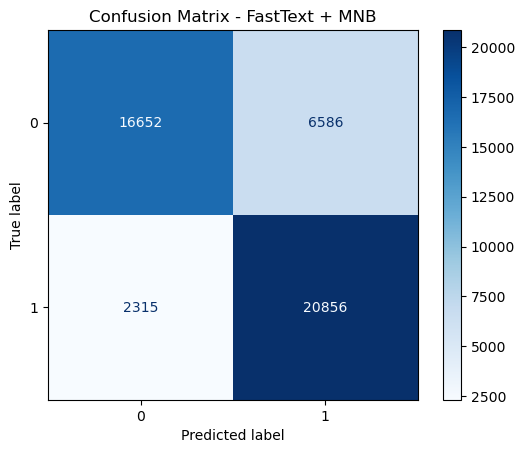

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
import fasttext.util
import numpy as np
import pandas as pd

# Load your preprocessed dataset
data = pd.read_excel(r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx")

# Features and target
X = data['cleaned_text']
y = data['encoded_class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load FastText word vectors
fasttext.util.download_model('en', if_exists='ignore')  # Download English model
ft = fasttext.load_model('cc.en.300.bin')

# Function to get average word vectors (with non-negative transformation)
def get_ft_vectors(texts):
    vectors = []
    for text in texts:
        if isinstance(text, str):  # Ensure the text is a string
            words = text.split()
            if words:
                word_vectors = [ft.get_word_vector(word) for word in words]
                avg_vector = np.mean(word_vectors, axis=0)
            else:
                avg_vector = np.zeros(300)
        else:
            avg_vector = np.zeros(300)  # Handle missing or non-string values
        # Apply ReLU to ensure non-negative values
        avg_vector = np.maximum(avg_vector, 0)  # ReLU (set negative values to 0)
        vectors.append(avg_vector)
    return np.array(vectors)

# Convert text to FastText vectors
X_train_ft = get_ft_vectors(X_train.fillna(''))  # Fill NaNs with empty string
X_test_ft = get_ft_vectors(X_test.fillna(''))  # Fill NaNs with empty string

# Classifier (using Multinomial Naive Bayes)
clf = MultinomialNB()
clf.fit(X_train_ft, y_train)

# Predictions
y_pred_ft = clf.predict(X_test_ft)

# Confusion Matrix
classes = np.unique(y)  # Assuming encoded_class has consistent labels
cm = confusion_matrix(y_test, y_pred_ft)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - FastText + MNB")
plt.show()


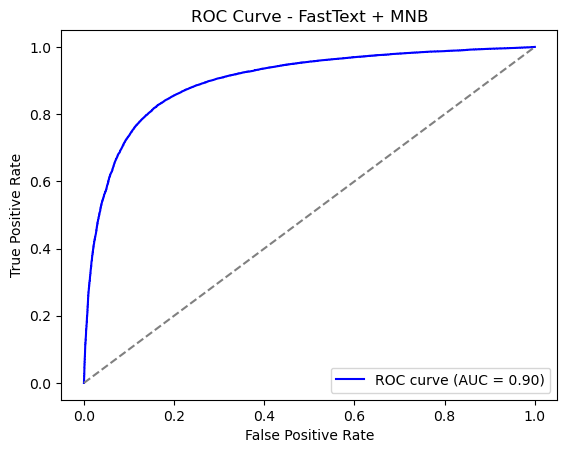

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
import fasttext.util
import numpy as np
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Load your preprocessed dataset
data = pd.read_excel(r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx")

# Features and target
X = data['cleaned_text']
y = data['encoded_class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load FastText word vectors
fasttext.util.download_model('en', if_exists='ignore')  # Download English model
ft = fasttext.load_model('cc.en.300.bin')

# Function to get average word vectors (with non-negative transformation)
def get_ft_vectors(texts):
    vectors = []
    for text in texts:
        if isinstance(text, str):  # Ensure the text is a string
            words = text.split()
            if words:
                word_vectors = [ft.get_word_vector(word) for word in words]
                avg_vector = np.mean(word_vectors, axis=0)
            else:
                avg_vector = np.zeros(300)
        else:
            avg_vector = np.zeros(300)  # Handle missing or non-string values
        # Apply ReLU to ensure non-negative values
        avg_vector = np.maximum(avg_vector, 0)  # ReLU (set negative values to 0)
        vectors.append(avg_vector)
    return np.array(vectors)

# Convert text to FastText vectors
X_train_ft = get_ft_vectors(X_train.fillna(''))  # Fill NaNs with empty string
X_test_ft = get_ft_vectors(X_test.fillna(''))  # Fill NaNs with empty string

# Classifier (using Multinomial Naive Bayes)
clf = MultinomialNB()
clf.fit(X_train_ft, y_train)

# Predictions
y_pred_ft = clf.predict(X_test_ft)
y_pred_prob = clf.predict_proba(X_test_ft)  # Get predicted probabilities

# Check if binary classification or multi-class
num_classes = len(np.unique(y))

# Binarize the labels for multi-class classification
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# Initialize dictionaries to store ROC curve data
fpr = {}
tpr = {}
roc_auc = {}

# Handle both binary and multi-class cases
if num_classes == 2:
    # For binary classification, we directly use the positive class probabilities
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob[:, 1])  # Using the second column for positive class
    roc_auc = auc(fpr, tpr)
else:
    # For multi-class, calculate ROC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure()
if num_classes == 2:
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
else:
    colors = ['blue', 'green', 'red', 'cyan', 'magenta']  # Adjust as necessary for the number of classes
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - FastText + MNB')
plt.legend(loc='lower right')
plt.show()


Mean Absolute Error (MAE): 0.1918
Mean Squared Error (MSE): 0.1918
Root Mean Squared Error (RMSE): 0.4379


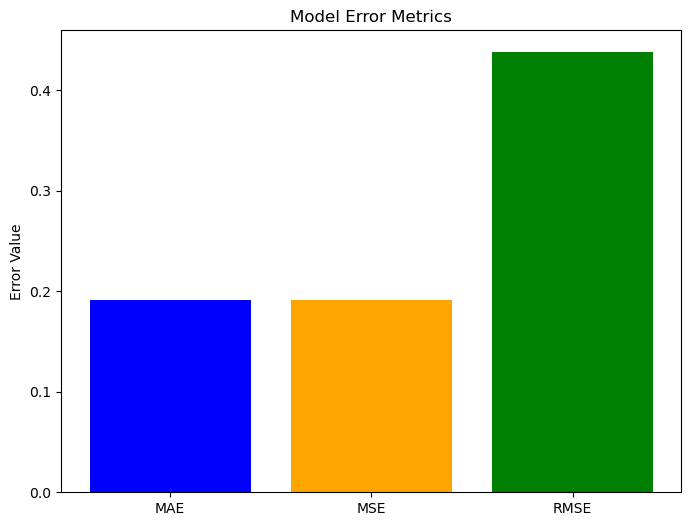

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Calculate MAE, MSE, and RMSE for the predictions
mae = mean_absolute_error(y_test, y_pred_ft)
mse = mean_squared_error(y_test, y_pred_ft)
rmse = np.sqrt(mse)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Create a bar chart to visualize MAE, MSE, RMSE
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'orange', 'green'])
plt.ylabel('Error Value')
plt.title('Model Error Metrics')
plt.show()


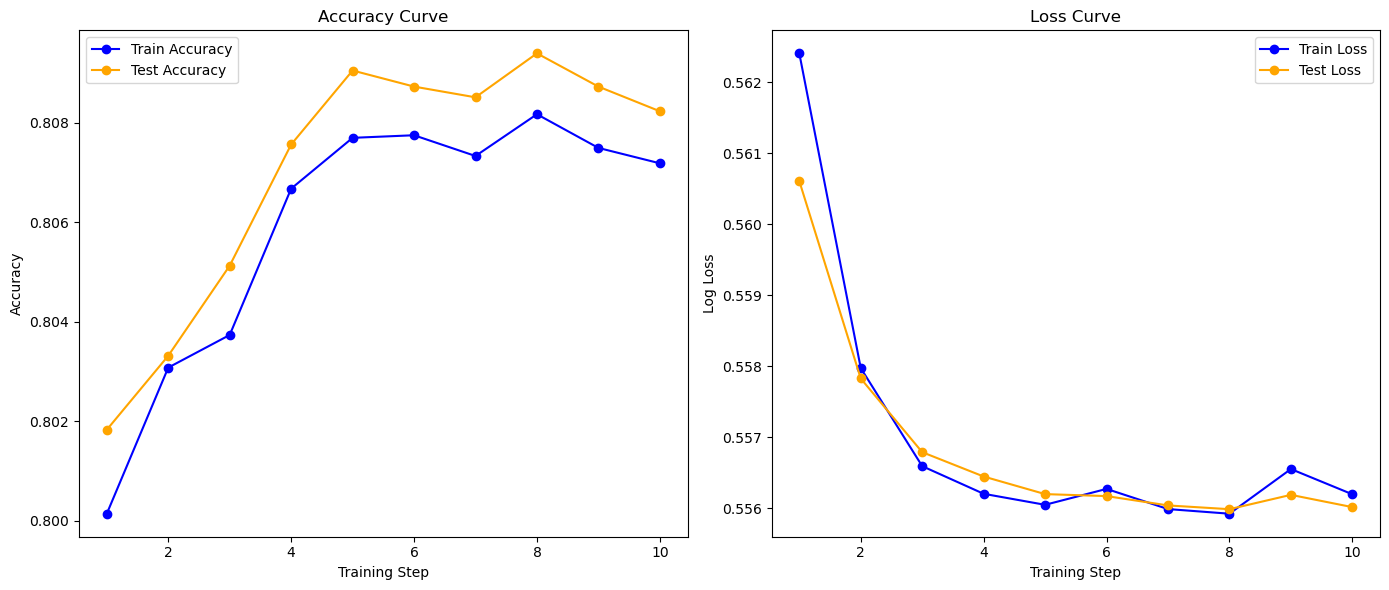

In [12]:
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import MultinomialNB

# Define number of steps for incremental training (simulation)
num_steps = 10
step_size = len(X_train_ft) // num_steps

# Initialize lists to store accuracy and loss at each step
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []

# Initialize classifier
clf = MultinomialNB()

# Simulate the training process by splitting into steps
for step in range(1, num_steps + 1):
    # Get the subset of the data for this step
    end_index = step * step_size
    X_train_step = X_train_ft[:end_index]
    y_train_step = y_train[:end_index]
    
    # Fit the model on the current subset of data
    clf.fit(X_train_step, y_train_step)
    
    # Predict and calculate accuracy and log loss for train and test data
    y_train_pred = clf.predict(X_train_step)
    y_train_prob = clf.predict_proba(X_train_step)
    
    y_test_pred = clf.predict(X_test_ft)
    y_test_prob = clf.predict_proba(X_test_ft)
    
    # Calculate training accuracy and log loss
    train_accuracy = accuracy_score(y_train_step, y_train_pred)
    train_loss = log_loss(y_train_step, y_train_prob)
    
    # Calculate test accuracy and log loss
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_loss = log_loss(y_test, y_test_prob)
    
    # Store the metrics
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Plot the accuracy and loss curves
plt.figure(figsize=(14, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_steps + 1), train_accuracies, label="Train Accuracy", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_accuracies, label="Test Accuracy", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_steps + 1), train_losses, label="Train Loss", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_losses, label="Test Loss", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Log Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()
